# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Step 2. Import the dataset

In [3]:
pd.read_csv('appl_1980_2014.csv')

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
...,...,...,...,...,...,...,...
8460,1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41
8461,1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
8462,1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
8463,1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42


### Step 3. Assign it to a variable apple

In [5]:
apple=pd.read_csv('appl_1980_2014.csv')

### Step 4.  Check out the type of the columns

In [8]:
print(apple.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object


### Step 5. Transform the Date column as a datetime type

In [10]:
apple['Date'] = pd.to_datetime(apple['Date'])
print(apple['Date'])

0      2014-07-08
1      2014-07-07
2      2014-07-03
3      2014-07-02
4      2014-07-01
          ...    
8460   1980-12-18
8461   1980-12-17
8462   1980-12-16
8463   1980-12-15
8464   1980-12-12
Name: Date, Length: 8465, dtype: datetime64[ns]


### Step 6.  Set the date as the index

In [11]:
apple.set_index('Date', inplace=True)

In [12]:
apple.index.name

'Date'

### Step 7.  Is there any duplicate dates?

In [18]:
counts = apple.index.value_counts()
for count in counts:
    if count>1:
        print('duplication founded')
    break
    

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [33]:
apple.index = apple.index.values[::-1]
apple

,Open,High,Low,Close,Volume,Adj Close,Date
1980-12-12,96.27,96.80,93.92,95.35,65130000,95.35,1980-12-12
1980-12-15,94.14,95.99,94.10,95.97,56305400,95.97,1980-12-15
1980-12-16,93.67,94.10,93.20,94.03,22891800,94.03,1980-12-16
1980-12-17,93.87,94.06,93.09,93.48,28420900,93.48,1980-12-17
1980-12-18,93.52,94.07,93.13,93.52,38170200,93.52,1980-12-18
...,...,...,...,...,...,...,...
2014-07-01,26.63,26.75,26.63,26.63,18362400,0.41,2014-07-01
2014-07-02,25.87,26.00,25.87,25.87,21610400,0.40,2014-07-02
2014-07-03,25.37,25.37,25.25,25.25,26432000,0.39,2014-07-03
2014-07-07,27.38,27.38,27.25,27.25,43971200,0.42,2014-07-07


### Step 9. Get the last business day of each month

In [36]:
from pandas.tseries.offsets import BMonthEnd

apple['last_business_day_of_month'] = apple['Date'] + BMonthEnd(0)

In [37]:
apple

,Open,High,Low,Close,Volume,Adj Close,Date,last_business_day_of_month
1980-12-12,96.27,96.80,93.92,95.35,65130000,95.35,1980-12-12,1980-12-31
1980-12-15,94.14,95.99,94.10,95.97,56305400,95.97,1980-12-15,1980-12-31
1980-12-16,93.67,94.10,93.20,94.03,22891800,94.03,1980-12-16,1980-12-31
1980-12-17,93.87,94.06,93.09,93.48,28420900,93.48,1980-12-17,1980-12-31
1980-12-18,93.52,94.07,93.13,93.52,38170200,93.52,1980-12-18,1980-12-31
...,...,...,...,...,...,...,...,...
2014-07-01,26.63,26.75,26.63,26.63,18362400,0.41,2014-07-01,2014-07-31
2014-07-02,25.87,26.00,25.87,25.87,21610400,0.40,2014-07-02,2014-07-31
2014-07-03,25.37,25.37,25.25,25.25,26432000,0.39,2014-07-03,2014-07-31
2014-07-07,27.38,27.38,27.25,27.25,43971200,0.42,2014-07-07,2014-07-31


### Step 10.  What is the difference in days between the first day and the oldest

In [39]:
apple['Date'][0]-apple['Date'][-1]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21780\2756906336.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  apple['Date'][0]-apple['Date'][-1]


Timedelta('-12261 days +00:00:00')

### Step 11.  How many months in the data we have?

In [40]:
(apple['Date'][-1].to_period('M') - apple['Date'][0].to_period('M')).n


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21780\3639932916.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (apple['Date'][-1].to_period('M') - apple['Date'][0].to_period('M')).n


403

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

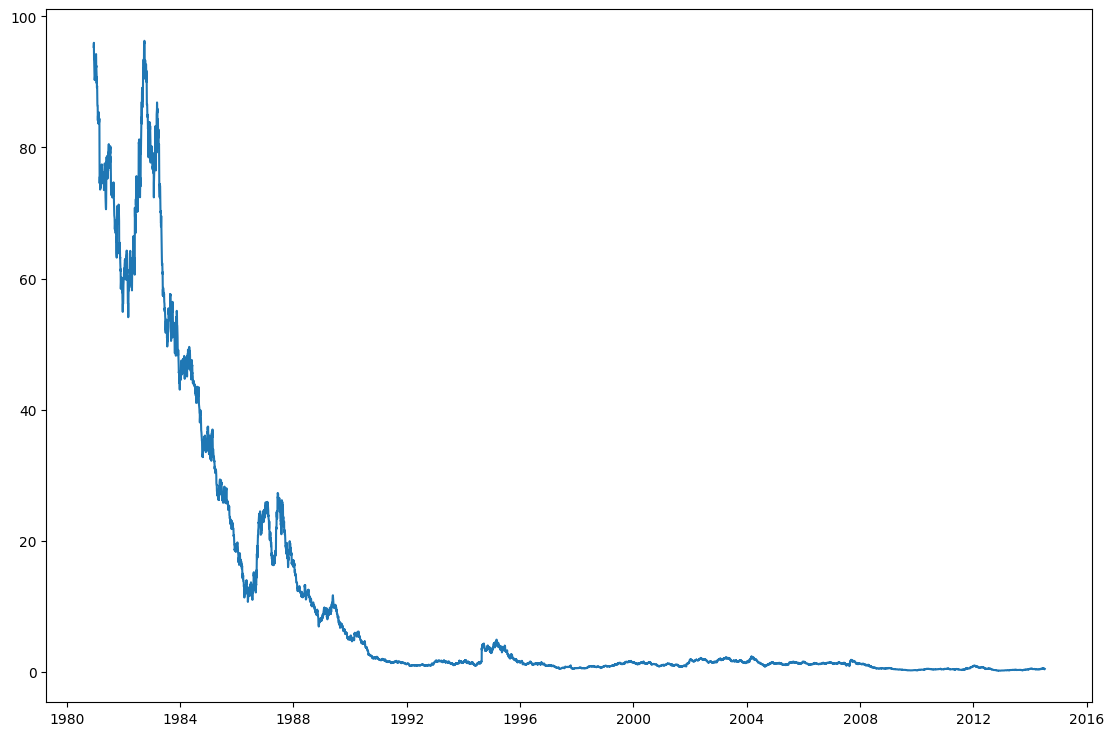

In [41]:
plt.figure(figsize=(13.5, 9))
plt.plot(apple['Adj Close'])

### BONUS: Create your own question and answer it.